## Settings and imports

In [1]:
import sys
sys.path.insert(1, '../src/')
from data_utils import *
from train_and_evaluate import *
from model import *

In [2]:
import json

with open('../config.json', 'r') as f:
    config = json.load(f)

PREPROCESSING_METHOD = config["preprocessing_method"] # normalization / logarithm
HOW_MANY_OUTER_TO_REMOVE = config["how_many_outer_to_remove"]
ELEMENTS_TO_KEEP = config["elements_to_keep"]
ELEMENTS_TO_KEEP_NO_FE = config["elements_to_keep_no_Fe"]
MULTIPLICATION_WEIGHTS = config["multiplication_weights"]
DROPOUT_PROB = config["dropout_prob"]

DATA_PATH = config["training_data_path"]
MODELS_PATH = config["models_path"]

## Loading the data

In [3]:
inDKs_df, inks_df, inds_df = load_training_data(DATA_PATH)

## Preprocessing

0. Keeping track of the records from the same sample

We will keep this info in 'Sample_id' and 'name' columns.

In [4]:
inDKs_df = create_sample_id(inDKs_df)

1. Let's remove 'outer' samples:

In [5]:
inDKs_df = remove_outer_samples(inDKs_df, HOW_MANY_OUTER_TO_REMOVE)

2. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 10. We will also use only 10 numbers as input.

In [6]:
inDKs_df = delete_elements(inDKs_df, ELEMENTS_TO_KEEP)

3. Let's remove rows with missing values if there are any.

In [7]:
inDKs_df = remove_missing_data(inDKs_df)

4. Let's set negative numbers to zeros. (First, check if there are any.)

In [8]:
inDKs_df = set_negative_to_zero(inDKs_df, ELEMENTS_TO_KEEP)

5. Let's multiply the indicators by weights (leave inks as they re)/

In [9]:
inDKs_df = divide_by_weights(inDKs_df, ELEMENTS_TO_KEEP, suffix='_i', weights=MULTIPLICATION_WEIGHTS)

6. Normalize with respect to Fe and remove Fe (both indicators and inks).

In [10]:
inDKs_df = normalize_to_Fe(inDKs_df, ELEMENTS_TO_KEEP)

7. Remove Fe.

In [11]:
inDKs_df = delete_elements(inDKs_df, ELEMENTS_TO_KEEP_NO_FE)

### Train test split, datasets, dataloaders

In [12]:
X_y_train, X_y_val, X_y_test = create_partition(inDKs_df)

### Creating features and labels matrices

In [13]:
X_train, y_train, X_val, y_val, X_test, y_test, train_order, val_order, test_order = prepare_data_for_training(
                                                                                                                X_y_train, 
                                                                                                                X_y_val, 
                                                                                                                X_y_test, 
                                                                                                                ELEMENTS_TO_KEEP_NO_FE)

### Normalization / taking logarithm

In [14]:
X_train = transform_data(X_train, 'logarithm')
y_train = transform_data(y_train, 'logarithm')
X_val = transform_data(X_val, 'logarithm')
y_val = transform_data(y_val, 'logarithm')
X_test = transform_data(X_test, 'logarithm')
y_test = transform_data(y_test, 'logarithm')

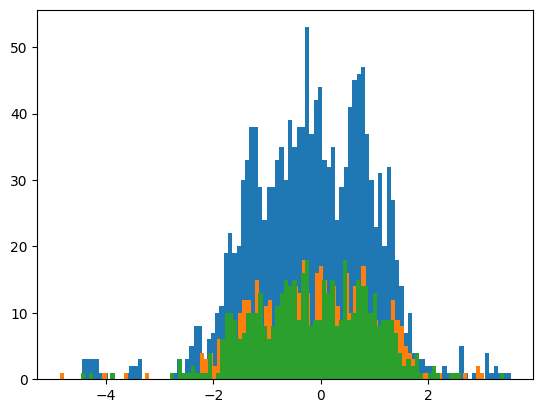

In [15]:
dim = 0
plt.hist(X_train[:,dim], bins=100);
plt.hist(X_val[:,dim], bins=100);
plt.hist(X_test[:,dim], bins=100);

### Converting to tensors

In [16]:
device = get_device()

Using cuda device


In [17]:
X_train = data_to_device(X_train, device)
y_train = data_to_device(y_train, device)
X_val = data_to_device(X_val, device)
y_val = data_to_device(y_val, device)
X_test = data_to_device(X_test, device)
y_test = data_to_device(y_test, device)

### Dataset

In [18]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [19]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=100)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Neural network

In [20]:
model = InksNet(input_size=INPUT_SIZE, dropout_prob=DROPOUT_PROB).to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=9, out_features=64, bias=True)
    (1): Dropout(p=0.07, inplace=False)
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=256, bias=True)
    (5): Dropout(p=0.07, inplace=False)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Linear(in_features=256, out_features=1024, bias=True)
    (9): Dropout(p=0.07, inplace=False)
    (10): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU()
    (12): Linear(in_features=1024, out_features=256, bias=True)
    (13): Dropout(p=0.07, inplace=False)
    (14): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): ReLU()
    (16): Linear(in_features=256, out_features=64, bias=True)
    (17): Dropout(p=0.07, inplace=False)
    (18): BatchNorm1d(64, eps=1

Cu >> Mn > Al > Zn > Pb > S > Cr > Co >>

In [23]:
weights = torch.tensor([1/INPUT_SIZE]*INPUT_SIZE).unsqueeze(1).to(device)
loss_fn = CustomLoss(weights=weights)

In [22]:
model, train_losses, val_losses = train_model(model=model,
                                              train_loader=train_loader,
                                              val_loader=val_loader,
                                              epochs=5000,
                                              loss_fn=loss_fn)

EPOCH 1:
LOSS train 5.791678778330485 test 5.775560384773346
EPOCH 2:
LOSS train 5.331750742594401 test 4.864107091264073
EPOCH 3:
LOSS train 4.828169218699137 test 4.092660080476937
EPOCH 4:
LOSS train 4.254591782887776 test 3.7290781985325028
EPOCH 5:
LOSS train 3.63034823735555 test 3.134193162123362
EPOCH 6:
LOSS train 3.0173174858093263 test 2.542300264998133
EPOCH 7:
LOSS train 2.462358490626017 test 2.2577048712466135
EPOCH 8:
LOSS train 1.971989917755127 test 1.6230240326569263
EPOCH 9:
LOSS train 1.6172335147857666 test 1.3810595064517484
EPOCH 10:
LOSS train 1.3365270694096882 test 1.2330300800771599
EPOCH 11:
LOSS train 1.1333178679148357 test 1.0140079205414378
EPOCH 12:
LOSS train 0.9998086214065551 test 0.9147282814883803
EPOCH 13:
LOSS train 0.9457593957583109 test 0.8574065919741091
EPOCH 14:
LOSS train 0.8929466843605042 test 0.8187145392399237
EPOCH 15:
LOSS train 0.869438381989797 test 0.8478016060997683
EPOCH 16:
LOSS train 0.834222960472107 test 0.7595423952223785


In [22]:
model, train_losses, val_losses = train_model(model=model,
                                              train_loader=train_loader,
                                              val_loader=val_loader,
                                              epochs=5000,
                                              loss_fn=loss_fn)

EPOCH 1:
LOSS train 5.76897996266683 test 5.808231933049887
EPOCH 2:
LOSS train 5.316135311126709 test 4.922797992526288
EPOCH 3:
LOSS train 4.81330238978068 test 4.200257320480653
EPOCH 4:
LOSS train 4.236019166310628 test 3.7390235090351487
EPOCH 5:
LOSS train 3.629625097910563 test 3.2236819588036902
EPOCH 6:
LOSS train 3.0190211137135825 test 2.7450895852831954
EPOCH 7:
LOSS train 2.456540330251058 test 2.104055571388528
EPOCH 8:
LOSS train 1.976224454243978 test 1.7257389399900016
EPOCH 9:
LOSS train 1.6061012109120687 test 1.4401006150437168
EPOCH 10:
LOSS train 1.3445615927378336 test 1.2658809558095703
EPOCH 11:
LOSS train 1.1326470057169595 test 1.0499465235744614
EPOCH 12:
LOSS train 0.9951711893081665 test 0.8885445837455103
EPOCH 13:
LOSS train 0.8855550130208333 test 0.7934754871161108
EPOCH 14:
LOSS train 0.851256807645162 test 0.8015041788778152
EPOCH 15:
LOSS train 0.8015041669209798 test 0.7195457341261657
EPOCH 16:
LOSS train 0.7686363180478414 test 0.7223306217167272

### Loss visualisation

In [22]:
#%matplotlib widget

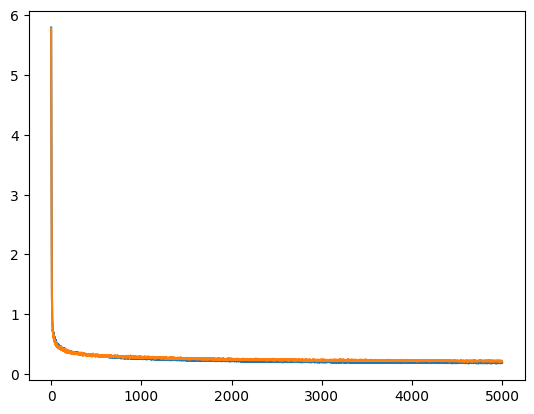

In [26]:
visualise_losses(train_losses, val_losses)

## Loading pretrained model

In [24]:
# model = InksNet(input_size=INPUT_SIZE, dropout_prob=DROPOUT_PROB).to(device)
# model.load_state_dict(torch.load(MODELS_PATH))

/tmp/ipykernel_7403/2341782259.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODELS_PATH))


<All keys matched successfully>

## Prediction on test set

In [27]:
labels, outputs, difference, mean_loss = evaluate_on_test_set(model=model, 
                                                              test_loader=test_loader, 
                                                              loss_fn=loss_fn)

Consecutive inks from test set are in labels tensor (498 examples, 10 elements/coordinates):

In [28]:
labels

tensor([[ -4.3209,  -6.1565,  -9.9935,  ...,  -6.3401,  -5.5264,   9.5189],
        [ -3.4265,  -5.6875,  -9.0043,  ...,  -8.3368,  -3.0887,   9.2628],
        [ -4.5778,  -5.6818, -10.0823,  ...,  -7.9772,  -5.7581,   8.8082],
        ...,
        [ -3.5898,  -5.2295, -10.0223,  ...,  -7.4466,  -4.4181,   9.3459],
        [ -4.0089,  -5.9244, -10.4436,  ...,  -8.8882,  -4.9559,  10.5740],
        [ -3.1474,  -4.6304,  -9.3687,  ...,  -4.7091,  -3.9306,   8.9485]],
       device='cuda:0')

Predictions are in out tensor (498 examples, 10 elements/coordinates):

In [29]:
outputs

tensor([[ -4.3192,  -6.1155,  -9.9277,  ...,  -6.1124,  -5.5826,   9.4535],
        [ -3.3450,  -5.6417,  -8.7099,  ...,  -8.3439,  -3.0625,   9.1194],
        [ -4.5479,  -5.5614, -10.6040,  ...,  -7.1960,  -5.7431,   9.1329],
        ...,
        [ -3.5205,  -5.5592,  -9.0741,  ...,  -7.9800,  -4.6247,   9.1646],
        [ -3.9870,  -5.7596, -10.2874,  ...,  -8.6464,  -4.8997,  10.3746],
        [ -3.4306,  -4.7377,  -9.3793,  ...,  -5.2481,  -2.7481,  10.1651]],
       device='cuda:0', grad_fn=<CatBackward0>)

Absolute value of difference between true values (labels) and prediction (outputs) are stored in difference tensor (498 examples, 10 elements/coordinates):

In [30]:
#difference

Mean loss:

In [29]:
mean_loss

0.1898058955613748

In [28]:
torch.mean(difference, axis=0)  # 9 elements, new data

tensor([0.1792, 0.1993, 0.4189, 0.1171, 0.1770, 0.1581, 0.2061, 0.1998, 0.1834],
       device='cuda:0', grad_fn=<MeanBackward1>)

Consecutive coordinates correspond to: Al, S, Cr, Mn, Co, Cu, Zn, Pb, Fe, Mg.

Significance of elements: Cu >> Mn > Al > Zn > Pb > S > Cr > Co >> all the others.

## Saving the model

In [54]:
save_model(model, MODELS_PATH, HOW_MANY_OUTER_TO_REMOVE, 
                ELEMENTS_TO_KEEP, PREPROCESSING_METHOD)

### Visualisations

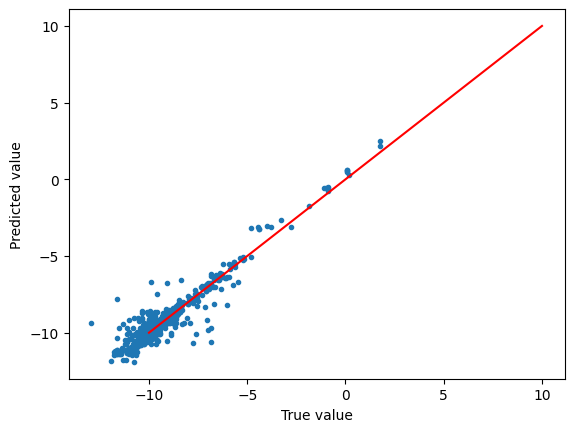

In [33]:
visualise_prediction_against_true(outputs, labels, dimension=2)

## Quality of prediction: closest points

### Creating df with means of classes

In [34]:
mean_df = create_means_df(ELEMENTS_TO_KEEP_NO_FE, y_train.cpu(), train_order, y_val.cpu(), val_order)

### Checking if there is any chance for it to work: if classes in y_test are close to means of classes in train_val set

In [35]:
y_test_df, consistency = find_and_compare_closest_class(y_test.cpu(), test_order, ELEMENTS_TO_KEEP_NO_FE, mean_df)

In [36]:
consistency

0.9698795180722891

### Now let's check if it works for the neural network's output.

In [37]:
model.eval()
outputs = model(X_test)

In [38]:
outputs_df, accuracy = find_and_compare_closest_class(outputs.cpu().detach().numpy(), test_order, ELEMENTS_TO_KEEP_NO_FE, mean_df)

In [39]:
accuracy = compute_accuracy(outputs_df)

Accuracy: 88.8%.


In [38]:
accuracy = compute_accuracy(outputs_df)

Accuracy: 88.2%.


In [41]:
precision, recall = compute_precision_and_recall(outputs_df)

Precision: 0.9185596310596311
Recall: 0.9010416666666666


/home/basia/Documents/atramenty/inks_repo/notebooks/../src/train_and_evaluate.py:193: RuntimeWarning: invalid value encountered in divide
  precision = tp / tp_and_fp
/home/basia/Documents/atramenty/inks_repo/notebooks/../src/train_and_evaluate.py:194: RuntimeWarning: invalid value encountered in divide
  recall = tp / tp_and_fn


In [39]:
precision, recall = compute_precision_and_recall(outputs_df)

Precision: 0.8968749999999999
Recall: 0.8988095238095237


/home/basia/Documents/atramenty/inks_repo/notebooks/../src/train_and_evaluate.py:193: RuntimeWarning: invalid value encountered in divide
  precision = tp / tp_and_fp
/home/basia/Documents/atramenty/inks_repo/notebooks/../src/train_and_evaluate.py:194: RuntimeWarning: invalid value encountered in divide
  recall = tp / tp_and_fn


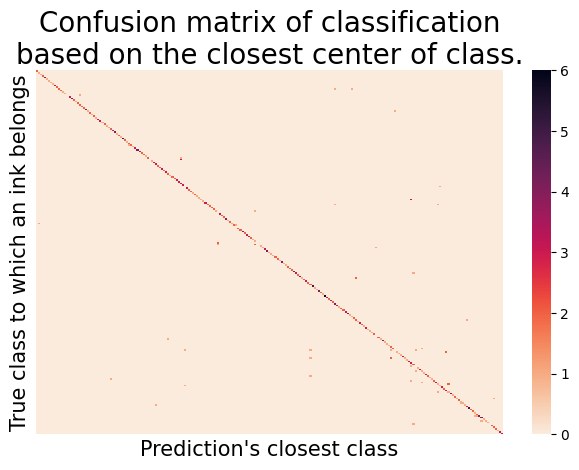

In [42]:
plot_confusion_matrix(true_labels = outputs_df['Real sample_id'], 
                      closest_labels = outputs_df['Closest sample id'], 
                      normalization_in_conf_mat = None, 
                      path_to_save = None)

## Quality of prediction: confidence intervals

In [43]:
model.eval()
outputs = model(X_test)

In [44]:
min_df, max_df, min_max_df = create_min_max_df(y_train.cpu(), 
                                               train_order, 
                                               y_val.cpu(), 
                                               val_order, 
                                               ELEMENTS_TO_KEEP_NO_FE)

In [45]:
lower_bound_df, upper_bound_df = create_mean_plus_sd_df(y_train.cpu(), 
                                                        train_order, 
                                                        y_val.cpu(), 
                                                        val_order, 
                                                        ELEMENTS_TO_KEEP_NO_FE, 
                                                        how_many_sd=2)

In [46]:
min_max_res_list, fraction_1 = is_inside_min_max_interval(outputs, test_order, min_df, max_df)

In [47]:
sd_res_list, fraction_2 = is_inside_mean_plus_minus_sd_interval(outputs, test_order, lower_bound_df, upper_bound_df)

Percentage of points inside min-max interval:

In [48]:
fraction_1

np.float64(0.6318607764390897)

On consecutive coordinates:

In [49]:
np.array(min_max_res_list).mean(0)

array([[0.57630522, 0.77108434, 0.77911647, 0.64859438, 0.54216867,
        0.51807229, 0.61646586, 0.64257028, 0.59236948]])

Percentage of points inside mean +- 2 standard deviations interval:

In [50]:
fraction_2

np.float64(0.7581436858545292)

On consecutive coordinates:

In [51]:
np.array(sd_res_list).mean(0)

array([[0.69879518, 0.87751004, 0.87951807, 0.76907631, 0.73493976,
        0.64658635, 0.71686747, 0.76706827, 0.73293173]])

### Visualisations of min-max intervals

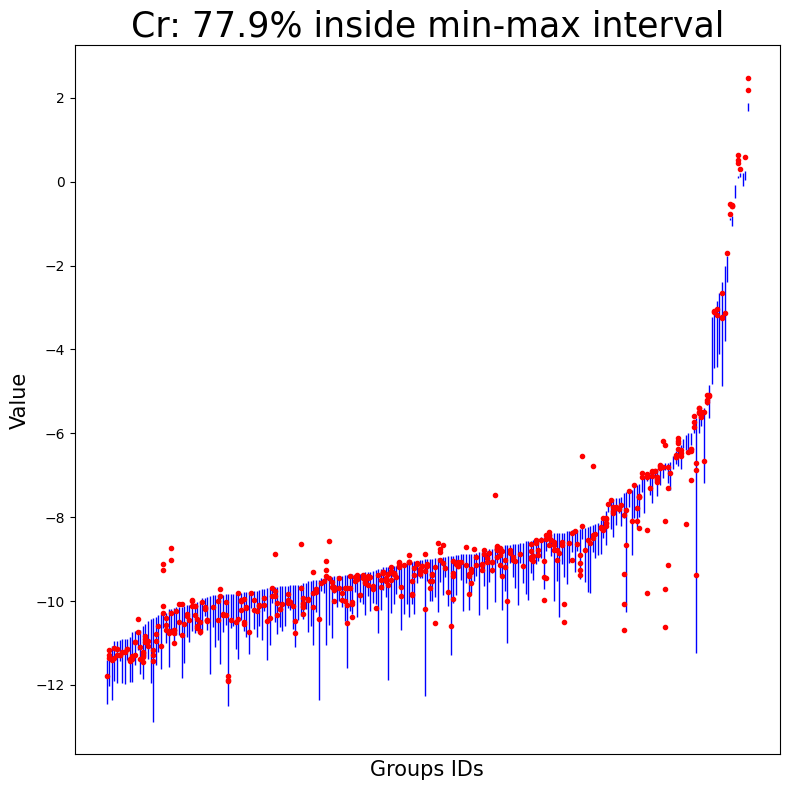

In [52]:
visualise_min_max_intervals(outputs, 
                            test_order, 
                            ELEMENTS_TO_KEEP_NO_FE, 
                            min_max_df, 
                            min_max_res_list, 
                            element_nr=2, 
                            path_to_save=None)

### Visualisations of mean +- 2 * standard deviation intervals

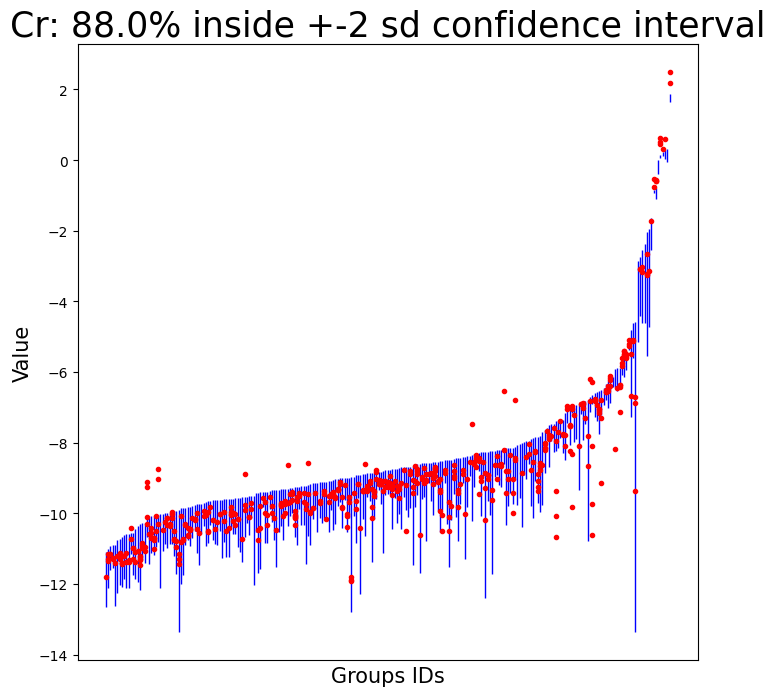

In [53]:
visualise_mean_plus_minus_sd_intervals(outputs, 
                                       test_order, 
                                        ELEMENTS_TO_KEEP_NO_FE, 
                                       lower_bound_df, 
                                       upper_bound_df, 
                                       how_many_sd=2,
                                       sd_res_list=sd_res_list, 
                                       element_nr=2, 
                                       path_to_save=None)